In [1]:
from PIL import Image
import cv2
import os
import matplotlib.pyplot as plt
import random
import torch
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import numpy as np
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor
from torchvision.models import mobilenet_v3_small
from pytorch_metric_learning import miners, losses
import scipy.io
import faiss
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = 'mps'

In [2]:
mat = scipy.io.loadmat('./devkit/cars_train_annos.mat')
fname_to_class = {fname: cl-1 for fname, cl in zip([i[0] for i in mat['annotations'][0]['fname']],
                                                   [i[0][0] for i in mat['annotations'][0]['class']])}
cars_meta = scipy.io.loadmat('./devkit/cars_meta.mat')
id_to_car = {idx: car[0]
             for idx, car in enumerate(cars_meta['class_names'][0])}

In [3]:
id_to_car

{0: np.str_('AM General Hummer SUV 2000'),
 1: np.str_('Acura RL Sedan 2012'),
 2: np.str_('Acura TL Sedan 2012'),
 3: np.str_('Acura TL Type-S 2008'),
 4: np.str_('Acura TSX Sedan 2012'),
 5: np.str_('Acura Integra Type R 2001'),
 6: np.str_('Acura ZDX Hatchback 2012'),
 7: np.str_('Aston Martin V8 Vantage Convertible 2012'),
 8: np.str_('Aston Martin V8 Vantage Coupe 2012'),
 9: np.str_('Aston Martin Virage Convertible 2012'),
 10: np.str_('Aston Martin Virage Coupe 2012'),
 11: np.str_('Audi RS 4 Convertible 2008'),
 12: np.str_('Audi A5 Coupe 2012'),
 13: np.str_('Audi TTS Coupe 2012'),
 14: np.str_('Audi R8 Coupe 2012'),
 15: np.str_('Audi V8 Sedan 1994'),
 16: np.str_('Audi 100 Sedan 1994'),
 17: np.str_('Audi 100 Wagon 1994'),
 18: np.str_('Audi TT Hatchback 2011'),
 19: np.str_('Audi S6 Sedan 2011'),
 20: np.str_('Audi S5 Convertible 2012'),
 21: np.str_('Audi S5 Coupe 2012'),
 22: np.str_('Audi S4 Sedan 2012'),
 23: np.str_('Audi S4 Sedan 2007'),
 24: np.str_('Audi TT RS Coupe

In [4]:
ADD_PATH = './devkit/cars_train/cars_train'

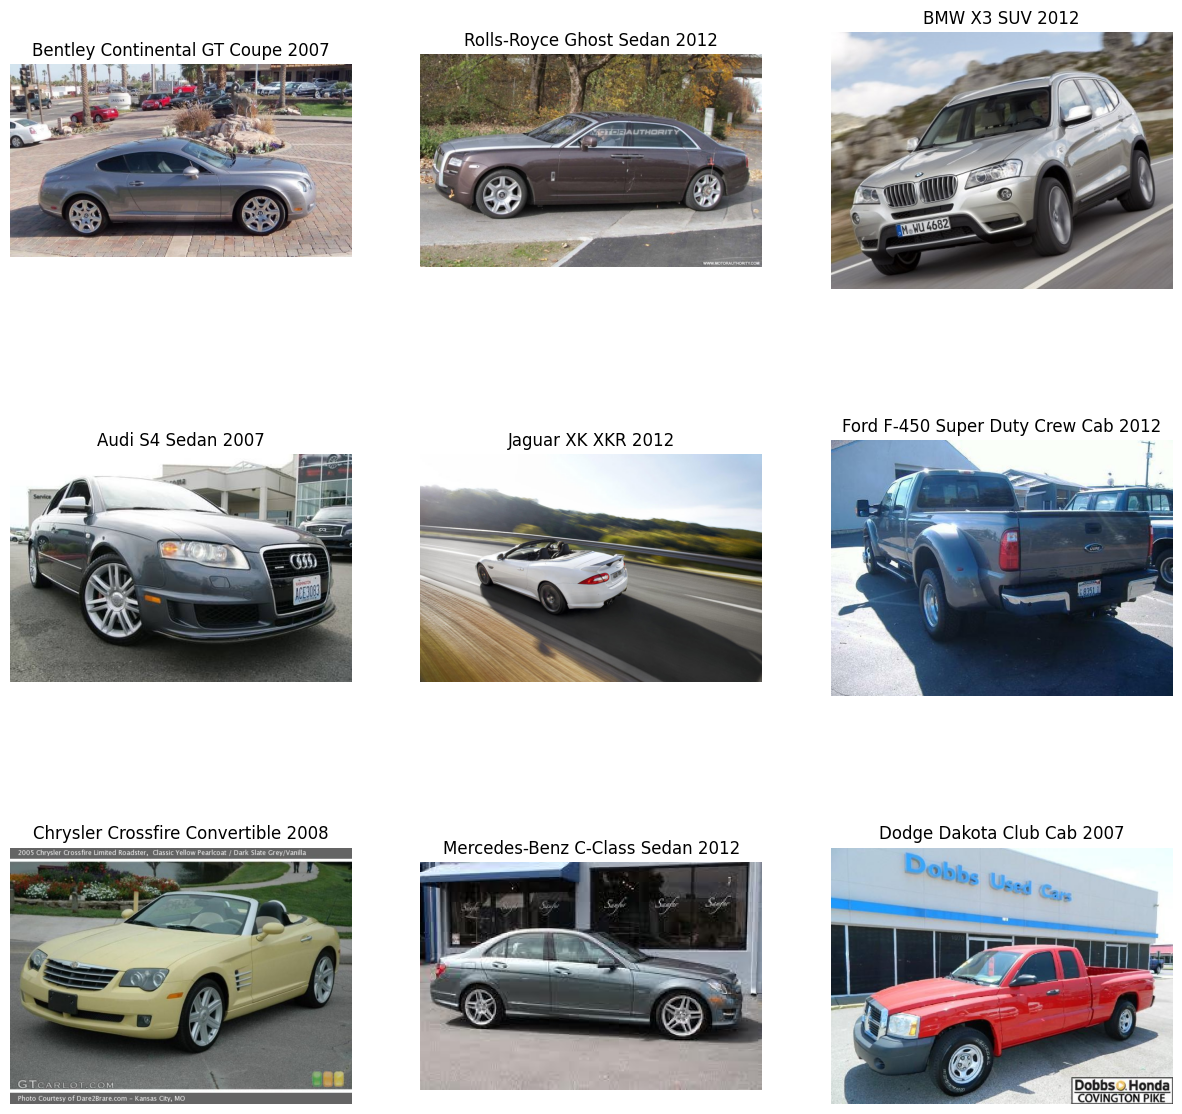

In [5]:
num_imgs = 9
cols = 3
rows = num_imgs // cols
fig, ax = plt.subplots(rows, cols, figsize=(15, 15))
for idx, im_idx in enumerate(random.sample([i for i in range(len(fname_to_class))], num_imgs)):
    filename, cl_id = list(fname_to_class.items())[im_idx]
    temp_image = cv2.imread(os.path.join(ADD_PATH, filename))
    temp_image = cv2.cvtColor(temp_image, cv2.COLOR_BGR2RGB)
    ax[idx//cols][idx % cols].imshow(temp_image)
    ax[idx//cols][idx % cols].set_title(f'{id_to_car[cl_id]}')
    ax[idx//cols][idx % cols].axis('off')

In [6]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.Resize(
        size=(224, 224)
    ),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class TripletDataset(torch.utils.data.Dataset):
    def __init__(self, cars_items, transforms):
        self.cars = cars_items
        self.transforms = transforms

    def __len__(self):
        return len(self.cars)

    def __getitem__(self, idx):
        filename, class_id = self.cars[idx]
        image = cv2.imread(os.path.join(ADD_PATH, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        return image, class_id

In [7]:
items = list(fname_to_class.items())
random.shuffle(items)
train_items = items[:int(len(items) * 0.8)]
val_items = items[int(len(items) * 0.8):]

train_dataset = TripletDataset(train_items, train_transforms)
val_dataset = TripletDataset(val_items, val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=True
)

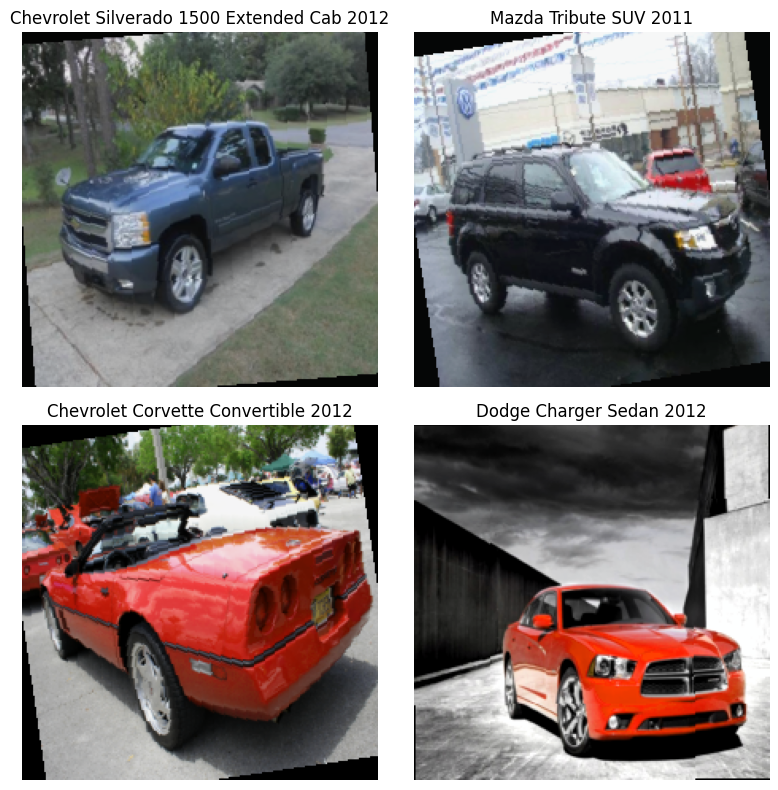

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
cols = 2
images_dict = next(iter(train_loader))
for idx in range(4):
    image = images_dict[0][idx]
    label = images_dict[1][idx].item()

    img_np = image.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    ax = axs[idx // cols, idx % cols]
    ax.imshow(img_np)
    ax.set_title(id_to_car[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
def precision_at_k(relevant_list, k):
    return sum(relevant_list[:k]) / k


def recall_at_k(relevant_list, k):

    return np.sum(relevant_list[:k]) / np.sum(relevant_list)


def average_precision(relevant_list):
    precisions = []
    relevant_count = 0

    for i, is_relevant in enumerate(relevant_list):
        if is_relevant:
            relevant_count += 1
            precision_at_i = relevant_count / (i + 1)
            precisions.append(precision_at_i)

    if not precisions:
        return 0.0

    return sum(precisions) / len(precisions)


def mean_average_precision(all_relevant_lists):
    aps = [average_precision(relevant_list)
           for relevant_list in all_relevant_lists]
    return sum(aps) / len(aps)

In [10]:
easy_miner = miners.TripletMarginMiner(margin=0.2, type_of_triplets="semihard")
triplet_loss = losses.TripletMarginLoss(margin=0.2)

In [11]:
for name, module in mobilenet_v3_small(pretrained=True).named_modules():
    print(name, module)

 MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1),

/opt/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
class CarEmbedder(pl.LightningModule):
    def __init__(self, learning_rate, emb_size):
        super().__init__()
        self.learning_rate = learning_rate

        self.model = mobilenet_v3_small(pretrained=True)

        self.model.classifier[3] = torch.nn.Linear(
            1024, emb_size)

        self.save_hyperparameters()

    def training_step(self, batch):
        images = batch[0]
        labels = batch[1].to(torch.long)
        embeddings = self.model(images)

        triplets = easy_miner(embeddings, labels)
        loss = triplet_loss(embeddings, labels, triplets)

        self.log("train_loss", loss, sync_dist=True)
        return loss

    def validation_step(self, batch):
        images = batch[0]
        labels = batch[1].to(torch.long)
        embeddings = self.model(images)

        triplets = easy_miner(embeddings, labels)
        loss = triplet_loss(embeddings, labels, triplets)

        self.log("validation_loss", loss, sync_dist=True)

    def forward(self, images):
        if len(images.shape) == 4:
            preds = self.model(images)
        else:
            preds = self.model(images.unsqueeze(0))
        return preds

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return [optimizer]

In [13]:
pl_model = CarEmbedder(3e-4, 512)
checkpoint_callback = ModelCheckpoint(
    monitor='validation_loss', mode='min',  save_top_k=3)
early_stopping = EarlyStopping(
    monitor="validation_loss", mode="min", patience=2)
lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=10,
    accelerator=device,
    devices=1,
    callbacks=[checkpoint_callback, early_stopping, lr_monitor])

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/miniconda3/envs/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [14]:
trainer.fit(model=pl_model, train_dataloaders=train_loader,
            val_dataloaders=val_loader)


  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | MobileNetV3 | 2.0 M  | train
----------------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
8.171     Total estimated model params size (MB)
209       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [15]:
trainer.validate(model=pl_model, dataloaders=val_loader)

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      validation_loss      │    0.09799180179834366    │
└───────────────────────────┴───────────────────────────┘

[{'validation_loss': 0.09799180179834366}]

In [16]:
def get_embeds(model, loader):
    model.eval()
    model.to(device)
    embeddings_list = []
    labels_list = []
    with torch.no_grad():
        for imgs, label in loader:
            preds = model(imgs.to(device))
            embeddings_list.append(preds.cpu().numpy())
            labels_list.append(label.numpy())
    embeddings = np.vstack(embeddings_list).astype(np.float32)
    labels = np.hstack(labels_list)
    return embeddings, labels

In [17]:
val_emb, val_labels = get_embeds(pl_model, val_loader)

In [18]:
dim = 512
index = faiss.IndexFlatL2(dim)

index.add(val_emb)

k = 11
_, I = index.search(val_emb[:5], k)
print(I)

[[   0  127  874  358 1480  975 1232 1286  519  362  739]
 [   1  444 1376  237 1543 1455  845 1282  947  950  351]
 [   2  516  581 1518  143 1007 1193  504 1167   11  100]
 [   3  223  442  189  342 1388  610 1005 1244  824  216]
 [   4 1002  503  747  667  498  288  857 1237  818 1127]]


In [19]:
true_labels = val_labels[:5]
nearest_labels = I[:, 1:]

In [20]:
true_labels

array([120, 151, 163,  50,  40], dtype=uint8)

In [21]:
nearest_labels

array([[ 127,  874,  358, 1480,  975, 1232, 1286,  519,  362,  739],
       [ 444, 1376,  237, 1543, 1455,  845, 1282,  947,  950,  351],
       [ 516,  581, 1518,  143, 1007, 1193,  504, 1167,   11,  100],
       [ 223,  442,  189,  342, 1388,  610, 1005, 1244,  824,  216],
       [1002,  503,  747,  667,  498,  288,  857, 1237,  818, 1127]])

In [22]:
preds = []
for i in range(5):
    label_i = true_labels[i]
    labels_i = nearest_labels[i]
    pred = (labels_i == label_i).astype(int)
    preds.append(pred)
    print(
        f'recall@10 = {recall_at_k(pred, 10)}, precision@10 = {precision_at_k(pred, 10)}')
print(f'mAP@10 = {mean_average_precision(preds)}')

recall@10 = nan, precision@10 = 0.0
recall@10 = nan, precision@10 = 0.0
recall@10 = nan, precision@10 = 0.0
recall@10 = nan, precision@10 = 0.0
recall@10 = nan, precision@10 = 0.0
mAP@10 = 0.0


/var/folders/66/ylwdy6t93213rp9v263z67tm0000gn/T/ipykernel_43034/3847527797.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum(relevant_list[:k]) / np.sum(relevant_list)


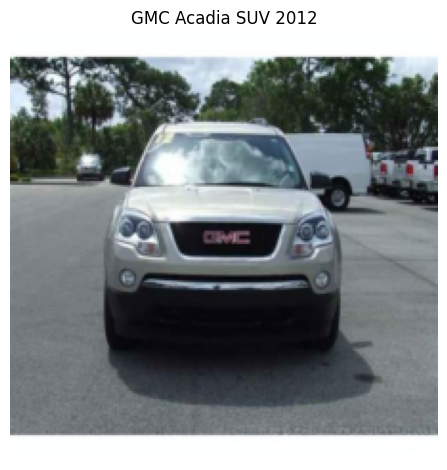

In [23]:
images_dict = next(iter(val_loader))
image = images_dict[0][0]
label = images_dict[1][0].item()

img_np = image.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = img_np * std + mean
img_np = np.clip(img_np, 0, 1)

plt.imshow(img_np)
plt.title(id_to_car[label])
plt.axis('off')

plt.tight_layout()
plt.show()

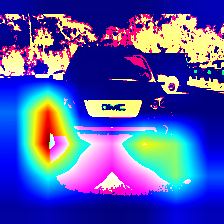

In [ ]:
imgs, labels = next(iter(val_loader))
img = imgs[0].unsqueeze(0).to(device)
label = labels[0].item()


class SimilarityToConceptTarget:
    def __init__(self, features):
        self.features = torch.tensor(features)

    def __call__(self, model_output):
        features = self.features.to(model_output.device).type_as(model_output)
        cos = torch.nn.CosineSimilarity(dim=0)
        return cos(model_output, features)


target_layers = [pl_model.model.features[-1]]
car_targets = [SimilarityToConceptTarget(val_emb[0])]
input_tensor = img
image_float = img.squeeze(0).permute(
    1, 2, 0).cpu().numpy().astype(np.float32) / 255.0

with GradCAM(model=pl_model.model, target_layers=target_layers) as cam:
    car_grayscale_cam = cam(input_tensor=input_tensor,
                            targets=car_targets)[0, :]

car_cam_image = show_cam_on_image(image_float, car_grayscale_cam, use_rgb=True)
Image.fromarray(car_cam_image)